In [401]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import plotly.graph_objects as go
from utils import metrics

In [ ]:
THRESHOLD = 10
THRESHOLD_HORIZONTAL = 10

def get_component_hists(img):
    r_hist, _ = np.histogram(img[:,0], bins=255, range=(0, 255))
    g_hist, _ = np.histogram(img[:,1], bins=255, range=(0, 255))
    b_hist, _ = np.histogram(img[:,2], bins=255, range=(0, 255))
    return (r_hist, g_hist, b_hist)



def line_difference_horizontal(img, start_coords : tuple, direction : tuple) -> tuple:
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_lab = img_lab.astype('float')
    img_hsv = img_hsv.astype('float')
    current_y = start_coords[0]
    current_x = start_coords[1]
    
    hist_l, hist_a, hist_b = get_component_hists(img_lab[:, current_x])
    hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[:, current_x + direction[1]])
    
    hist_h, hist_s, hist_v = get_component_hists(img_hsv[:, current_x])
    hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[:, current_x + direction[1]])
    
    difference = np.sum([
                  metrics.canberra_distance(hist_a, hist_new_a) * 0.45,
                  metrics.canberra_distance(hist_b, hist_new_b) * 0.45,
                  metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
    
    while difference < THRESHOLD_HORIZONTAL:
        current_x += direction[1]
        hist_l, hist_a, hist_b = get_component_hists(img_lab[:, current_x])
        hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[:, current_x + direction[1]])
        
        hist_h, hist_s, hist_v = get_component_hists(img_hsv[:, current_x])
        hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[:, current_x + direction[1]])
        
        difference = np.sum([
                    metrics.canberra_distance(hist_a, hist_new_a) * 0.45,
                    metrics.canberra_distance(hist_b, hist_new_b) * 0.45,
                    metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
        #print(difference)
    
    print(difference)
    return (current_y, current_x)
    

def line_difference_vertical(img, start_coords : tuple, direction : tuple) -> tuple:
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_lab = img_lab.astype('float')
    img_hsv = img_hsv.astype('float')
    current_y = start_coords[0]
    current_x = start_coords[1]
    
    hist_l, hist_a, hist_b = get_component_hists(img_lab[current_y])
    hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[current_y + direction[0]])
    
    hist_h, hist_s, hist_v = get_component_hists(img_hsv[current_y])
    hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[current_y + direction[0]])
    
    difference = np.sum([
                  metrics.canberra_distance(hist_a, hist_new_a) * 0.45,
                  metrics.canberra_distance(hist_b, hist_new_b) * 0.45,
                  metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
    
    while difference < THRESHOLD:
        current_y += direction[0]
        hist_l, hist_a, hist_b = get_component_hists(img_lab[current_y])
        hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[current_y + direction[0]])
        
        hist_h, hist_s, hist_v = get_component_hists(img_hsv[current_y])
        hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[current_y + direction[0]])
        
        difference = np.sum([
                  metrics.canberra_distance(hist_a, hist_new_a) * 0.45,
                  metrics.canberra_distance(hist_b, hist_new_b) * 0.45,
                  metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
        #print(difference)
    
    print(difference)
    return (current_y, current_x)


def get_histogram_peak(img, n_bins=255, n_range=(0, 256)):
    img = img.astype(np.uint8)
    weights = (img != 0).astype(int)
    hist, _ = np.histogram(img, bins=n_bins, range=n_range, weights=weights)
    hist = hist.astype(np.float32)
    hist /= np.sum(hist)

    smooth_hist = gaussian_filter1d(hist, sigma=4)
    main_peak = np.argmax(smooth_hist)
    threshold = smooth_hist[main_peak] * 0.8
    

    left = main_peak
    while left > 0 and smooth_hist[left] > smooth_hist[left - 1]:
        left -= 1
        
    right = main_peak
    while right < len(smooth_hist) - 1 and smooth_hist[right] > smooth_hist[right + 1]:
        right += 1
        
    plt.bar(range(len(smooth_hist)), smooth_hist)
    plt.axvline(left)
    plt.axvline(right)
    plt.show()
        
    return (left, right)

def get_histogram_peaks(img) -> list:
    img = img.astype(np.uint8)
    r, g, b = img[:, :, 0], img[:, :, 1], img[:, :, 2]
    
    left_r, right_r = get_histogram_peak(r)
    left_g, right_g = get_histogram_peak(g)
    left_b, right_b = get_histogram_peak(b)
    
    return (left_r, right_r), (left_g, right_g), (left_b, right_b)

def hist_remove_borders(img):
    top_border = img.copy()

    top_lab = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(top_lab)
    left, right = get_histogram_peak(s)

    top_border[(s < left) | (s > right)] = 0
    return top_border

def compute_line(point1, point2):
    
    A = point1[1] - point2[1]
    B = point2[0] - point1[0]
    C = point1[0]*point2[1] - point2[0]*point1[1]
    
    if B != 0:
        m = -A / B
        b = -C / B
    else:
        m = 0
        b = -C/A
    
    def line_func(x):
        return m*x + b
    
    return line_func

(1665, 2071, 3)
14.878125501864215
11.179100258056167
10.565746350762392
10.687695019673088


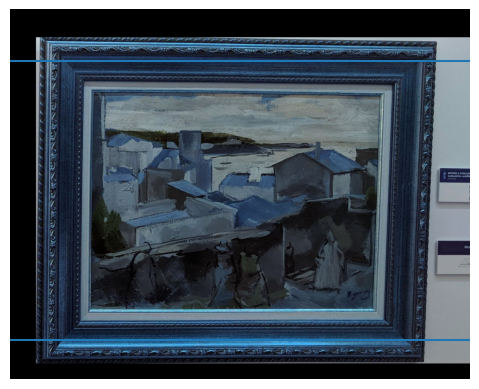

In [403]:

ADVANCE_PIXELS = 50

img = cv2.imread("data/qsd2_w1/00012.jpg", cv2.IMREAD_UNCHANGED)
print(img.shape)
middle_x = img.shape[1]//2
middle_y = img.shape[0]//2
shift = middle_x // 8
shift_y = middle_y // 8


#We look from the top
top_point = line_difference_vertical(
    img, start_coords=(0, middle_x-shift), direction=(1,0))

bottom_point = line_difference_vertical(
    img, start_coords=(img.shape[0] - 1, middle_x-shift), direction=(-1, 0))

left_point = line_difference_horizontal(
    img, start_coords=(top_point[0]+ADVANCE_PIXELS, 0), direction=(0, 1))
"""left_point_bottom = line_difference(
    img, start_coords=(bottom_point_left[0]-ADVANCE_PIXELS, 0), direction=(0, 1))"""

right_point = line_difference_horizontal(
    img, start_coords=(top_point[0]+ADVANCE_PIXELS, img.shape[1] - 1), direction=(0, -1))
"""right_point_bottom = line_difference(
    img, start_coords=(bottom_point_right[0]-ADVANCE_PIXELS, img.shape[1] - 1), direction=(0, -1))

left_line_func = compute_line(left_point_top, left_point_bottom)

y = np.array([int(left_line_func(x)) for x in range(img.shape[0])])
img = img.astype(np.uint8)

W = img.shape[1]
cols = np.arange(W)
mask = cols < y[:, None]
print(y.shape)"""

border_image = img.copy()

border_image[range(top_point[0]), :, :] = 0
border_image[range(img.shape[0] - 1, bottom_point[0], -1), :, :] = 0
border_image[:, range(left_point[1]), :] = 0
border_image[:, range(img.shape[1] - 1, right_point[1], -1), :] = 0
#img[mask] = 0

plt.imshow(border_image)
plt.axhline(top_point[0]+shift_y)
plt.axhline(bottom_point[0]-shift_y)
plt.axis('off')
plt.show()

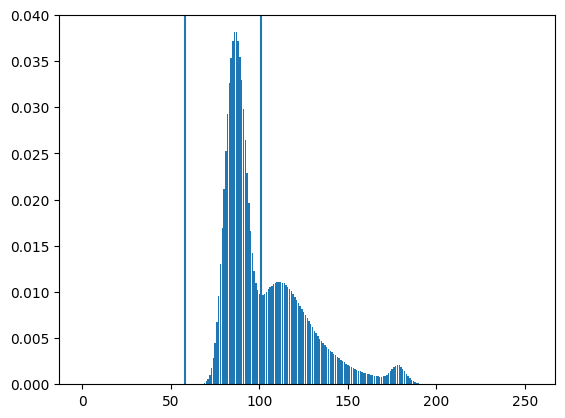

(165892, 3)


ValueError: could not broadcast input array from shape (25,1963,3) into shape (25,1959,3)

In [404]:
patches = [
    (top_point[0] - 5, top_point[0] + 20, left_point[1] - 5, right_point[1] + 5),
    (bottom_point[0] - 20, bottom_point[0] + 5, left_point[1] - 5, right_point[1] + 5),
    (top_point[0] - 5, bottom_point[0] + 5, left_point[1] - 5, left_point[1] + 20),
    (top_point[0] - 5, bottom_point[0] + 5, right_point[1] - 20, right_point[1] + 5)
]

patch_pixels = []
for (y1, y2, x1, x2) in patches:
    patch = img[y1:y2, x1:x2]
    patch_pixels.append(patch.reshape(-1, 1, 3))
    
borders = np.concatenate(patch_pixels, axis=0)

borders_lab = cv2.cvtColor(borders, cv2.COLOR_BGR2LAB)
borders_hsv = cv2.cvtColor(borders, cv2.COLOR_BGR2HSV)
looked = 0.3*borders_lab[:, :, 1] + 0.3*borders_lab[: , :, 2] + 0.4*borders_hsv[:, :, 1]
left, right = get_histogram_peak(looked)

borders[(looked < left) | (looked > right)] = 0

borders = borders.reshape(-1, 3)
print(borders.shape)
suma = 0
orig=img.copy()
for (y1, y2, x1, x2) in patches:
    pixel_number = (y2 - y1) * (x2 - x1)
    img[y1:y2, x1:x2] = borders[suma:suma+pixel_number].reshape(((y2 - y1), (x2- x1), 3))
    suma += pixel_number


f, ax = plt.subplots(1,3, figsize=(14, 10))
ax[0].imshow(img)
ax[1].imshow(orig)
rest = orig - img
rest[rest != 0] = 255
ax[2].imshow(rest)
plt.show()